# Preprocessing of EEG Data (ERP CORE, sub-001, Flanker Task)


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import mne

In [2]:
data_path = mne.datasets.erp_core.data_path()
print(data_path)

C:\Users\Lenovo\mne_data\MNE-ERP-CORE-data


In [3]:
raw_file = data_path / "ERP-CORE_Subject-001_Task-Flankers_eeg.fif"
raw = mne.io.read_raw_fif(raw_file, preload=True)
raw

Opening raw data file C:\Users\Lenovo\mne_data\MNE-ERP-CORE-data\ERP-CORE_Subject-001_Task-Flankers_eeg.fif...
    Range : 0 ... 935935 =      0.000 ...   913.999 secs
Ready.
Reading 0 ... 935935  =      0.000 ...   913.999 secs...


<Raw | ERP-CORE_Subject-001_Task-Flankers_eeg.fif, 33 x 935936 (914.0 s), ~235.7 MiB, data loaded>

## Step 1: Power Spectrum of the Raw Data

**Goal:** To characterize the spectral content of the raw (unfiltered) EEG,
including line noise and posterior alpha activity, and to examine how the
Welch window length affects frequency resolution and the variance of the
spectral estimate.

Effective window size : 2.000 (s)
[0.  0.5 1.  1.5 2. ]
Plotting power spectral density (dB=True).


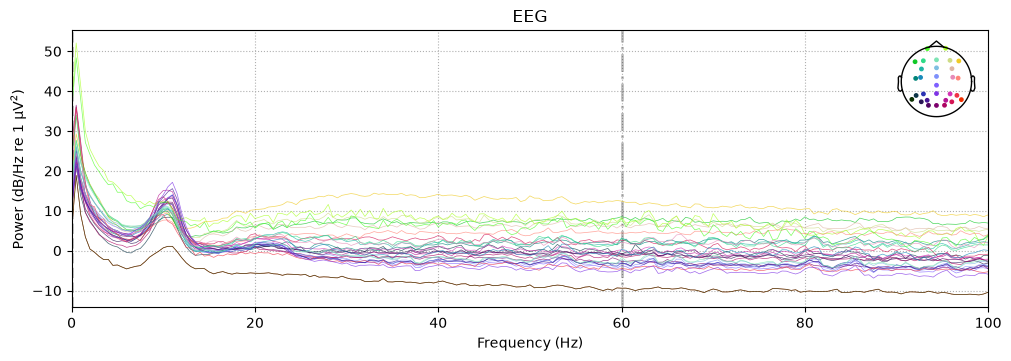

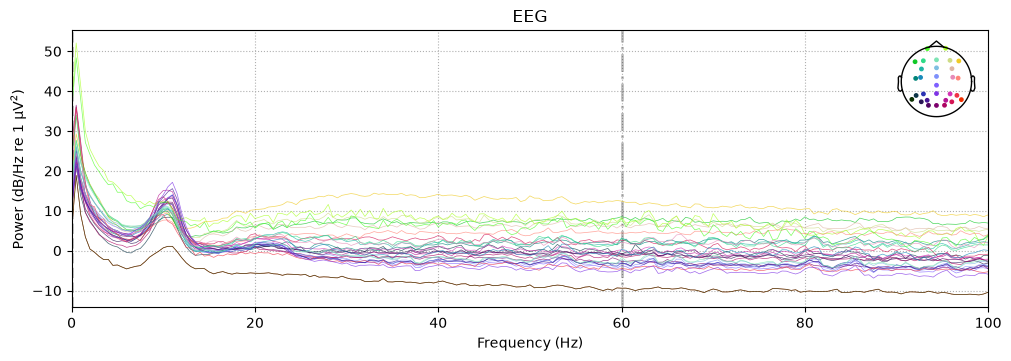

In [4]:
spectrum_2s = raw.compute_psd(method="welch", fmax=100, n_fft=2048)
print(spectrum_2s.freqs[:5])
spectrum_2s.plot(picks="eeg", average=False, amplitude=False)

Effective window size : 16.000 (s)
[0.     0.0625 0.125  0.1875 0.25  ]
Plotting power spectral density (dB=True).


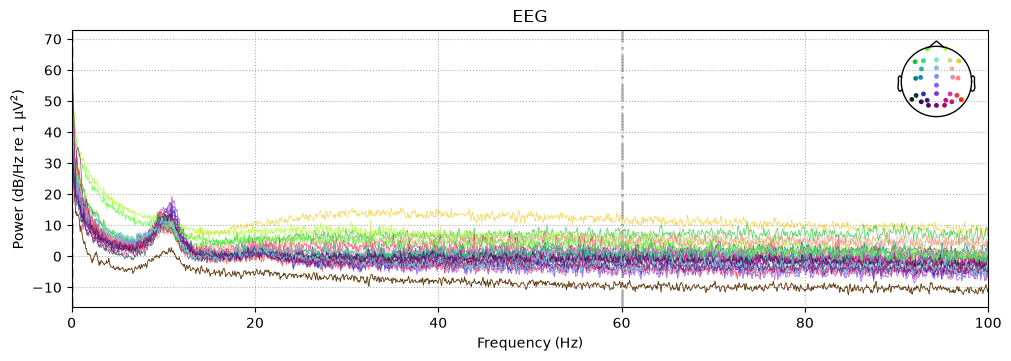

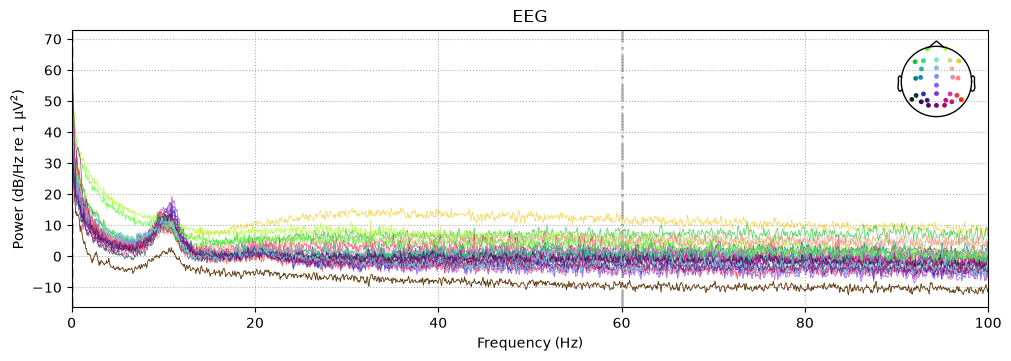

In [5]:
spectrum_16s = raw.compute_psd(method="welch", fmax=100, n_fft=16384)
print(spectrum_16s.freqs[:5])
spectrum_16s.plot(picks="eeg", average=False, amplitude=False)

In [6]:
posterior = ["O1", "Oz", "O2", "PO3", "PO4"]
psd, freqs = spectrum_16s.get_data(picks=posterior, return_freqs=True)

mean_psd = psd.mean(axis=0)
alpha_mask = (freqs >= 7) & (freqs <= 14)

alpha_freqs = freqs[alpha_mask]
alpha_psd = mean_psd[alpha_mask]

peak_idx = np.argmax(alpha_psd)

iaf = alpha_freqs[peak_idx]
peak_power = alpha_psd[peak_idx] * 1e12

print(f"Peak power: {peak_power:.2f} µV²/Hz")
print(f"Individual alpha frequency: {iaf:.2f} Hz")

Peak power: 36.50 µV²/Hz
Individual alpha frequency: 10.94 Hz


In [7]:
frontal = ["Fz", "FCz", "Cz"]
psd, freqs = spectrum_16s.get_data(picks=frontal, return_freqs=True)

mean_psd = psd.mean(axis=0)
alpha_mask = (freqs >= 7) & (freqs <= 14)

alpha_freqs = freqs[alpha_mask]
alpha_psd = mean_psd[alpha_mask]

peak_idx = np.argmax(alpha_psd)

iaf = alpha_freqs[peak_idx]
peak_power = alpha_psd[peak_idx] * 1e12

print(f"Peak power: {peak_power:.2f} µV²/Hz")
print(f"Individual alpha frequency: {iaf:.2f} Hz")

Peak power: 15.50 µV²/Hz
Individual alpha frequency: 9.94 Hz


### Physiological interpretation

Alpha activity was compared between a posterior cluster (O1, Oz, O2, PO3, PO4)
and a fronto-central cluster (Fz, FCz, Cz), using Welch's method with 16-s
windows (frequency resolution: 0.0625 Hz). The posterior cluster showed a
spectral peak at 10.94 Hz (peak power: 36.5 µV²/Hz), whereas the fronto-central
peak was at 9.94 Hz (15.5 µV²/Hz), corresponding to approximately 2.4-fold
higher alpha power over posterior sites.

The posterior predominance of alpha power is consistent with its primary
generators in occipito-parietal cortex; the weaker fronto-central alpha likely
reflects, at least in part, volume conduction from these posterior sources.
The lower peak frequency at fronto-central sites may indicate a contribution
from the sensorimotor mu rhythm, which is relevant given the manual responses
required by the task. However, because this estimate is based on a single
participant and a relatively noisy spectrum (~57 windows), the 1-Hz difference
should be interpreted with caution.

## Step 2: High-Pass Filtering

**Goal:** To apply a 0.1 Hz high-pass filter to the raw EEG data and to compare
the signal before and after filtering in both the frequency domain
(power spectral density) and the time domain.

In [8]:
raw_hp = raw.copy().filter(l_freq=0.1, h_freq=None, picks=["eeg", "eog"])

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Filter length: 33793 samples (33.001 s)



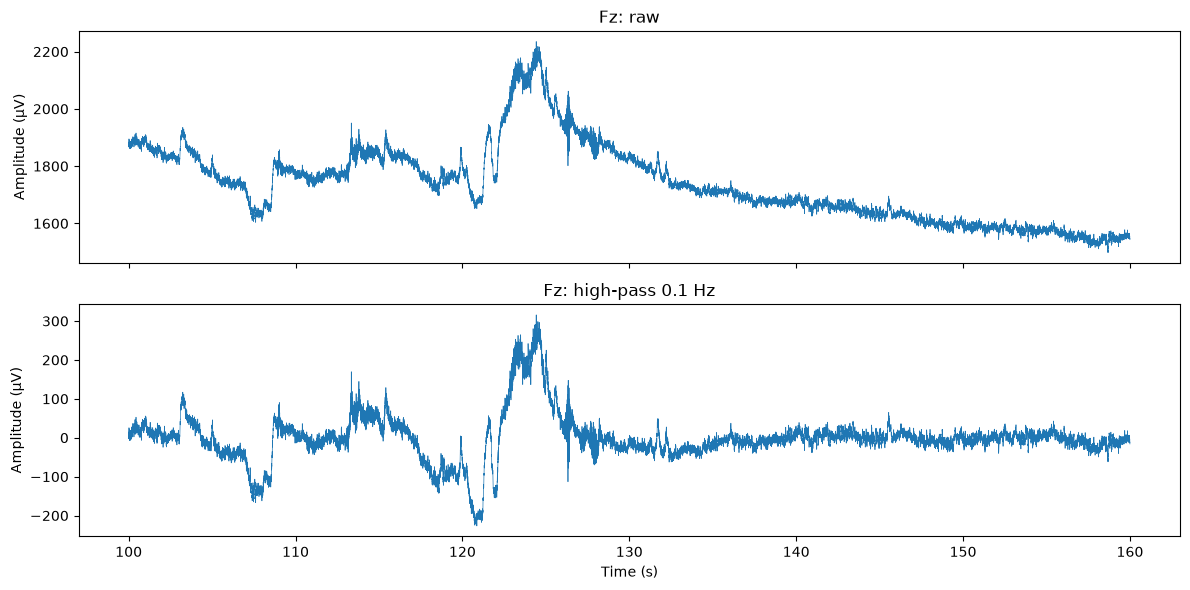

In [9]:
ch = "Fz"
start, stop = raw.time_as_index([100, 160])
times = raw.times[start:stop]

data_raw = raw.get_data(picks=ch, start=start, stop=stop)[0] * 1e6
data_hp = raw_hp.get_data(picks=ch, start=start, stop=stop)[0] * 1e6

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(times, data_raw, linewidth=0.5)
axes[0].set(ylabel="Amplitude (µV)", title=f"{ch}: raw")
axes[1].plot(times, data_hp, linewidth=0.5)
axes[1].set(xlabel="Time (s)", ylabel="Amplitude (µV)", title=f"{ch}: high-pass 0.1 Hz")
plt.tight_layout()
plt.show()

In [10]:
raw_hp_1 = raw.copy().filter(l_freq=1, h_freq=None, picks=["eeg", "eog"])

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3381 samples (3.302 s)



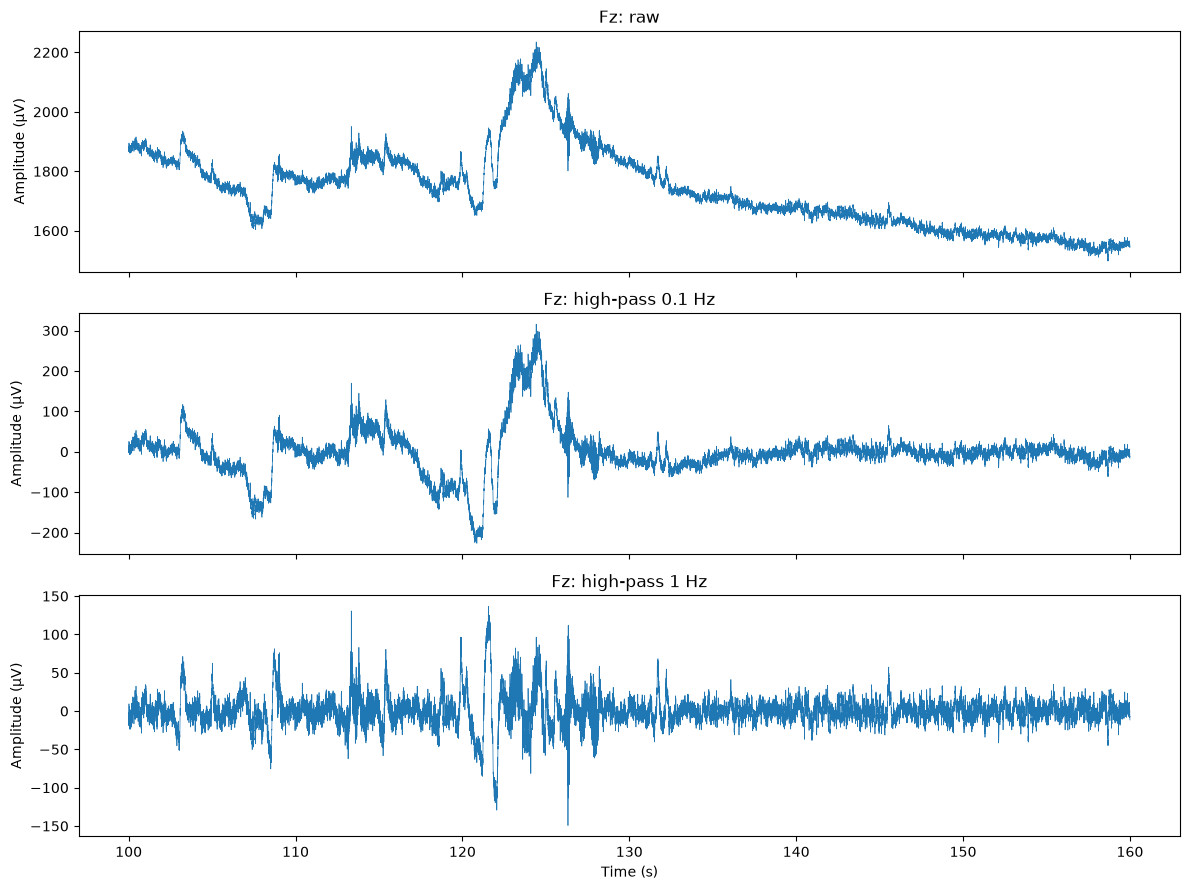

In [11]:
ch = "Fz"
start, stop = raw.time_as_index([100, 160])
times = raw.times[start:stop]

data_raw = raw.get_data(picks=ch, start=start, stop=stop)[0] * 1e6
data_hp = raw_hp.get_data(picks=ch, start=start, stop=stop)[0] * 1e6
data_hp_1 = raw_hp_1.get_data(picks=ch, start=start, stop=stop)[0] * 1e6

signals = [
    (data_raw, "raw"),
    (data_hp, "high-pass 0.1 Hz"),
    (data_hp_1, "high-pass 1 Hz"),
]

fig, axes = plt.subplots(len(signals), 1, figsize=(12, 9), sharex=True)
for ax, (data, label) in zip(axes, signals):
    ax.plot(times, data, linewidth=0.5)
    ax.set(ylabel="Amplitude (µV)", title=f"{ch}: {label}")
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

In [12]:
# Free memory: the 1 Hz copy was only needed for the comparison above
del raw_hp_1

### Physiological interpretation

The unfiltered signal at Fz showed a large DC offset (approximately
1,600–2,200 µV) and slow drifts of non-neural origin (e.g., skin potentials
and electrode polarization), exceeding typical EEG amplitudes (tens of µV)
by about two orders of magnitude. A zero-phase FIR high-pass filter at 0.1 Hz
(transition bandwidth: 0.1 Hz; filter length: 33 s) removed the offset and
the slow drift while leaving faster activity largely unchanged. Large
artifacts with a time scale of a few seconds (e.g., the ~300 µV deflection
at 123–126 s, ~0.2 Hz) were not removed, as their frequency content lies
within the passband; these will be addressed by ICA and artifact rejection.

A 1 Hz cutoff further attenuated these slow deflections but distorted the
signal: abrupt transients were followed by deflections of opposite polarity
that were absent in the 0.1 Hz-filtered data. Such filter-induced artifacts
are of particular concern for error-related analyses, because attenuating
the slow error positivity (Pe) may introduce a spurious negativity in the
ERN time window (Tanner et al., 2015). Therefore, a 0.1 Hz cutoff was
retained for ERP analyses, whereas a 1 Hz-filtered copy may be used for
ICA decomposition.